In [58]:
import pandas as pd
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# load the data
data = pd.read_excel("data.xlsx", sheet_name="FIFA 22")
data = data.dropna(subset=["value_eur"])

,Kolonne,Q1,Q3,IQR,Outliers,Procent
10,weak_foot,3.0,3.0,0.0,7381,38.512914
3,wage_eur,1000.0,8000.0,7000.0,2395,12.496739
2,value_eur,475000.0,2000000.0,1525000.0,2235,11.661884
27,skill_ball_control,55.0,69.0,14.0,2207,11.515784
49,goalkeeping_kicking,8.0,14.0,6.0,2131,11.119228
51,goalkeeping_reflexes,8.0,14.0,6.0,2128,11.103574
50,goalkeeping_positioning,8.0,14.0,6.0,2127,11.098356
48,goalkeeping_handling,8.0,14.0,6.0,2127,11.098356
47,goalkeeping_diving,8.0,14.0,6.0,2127,11.098356
23,skill_dribbling,50.0,68.0,18.0,2111,11.014871


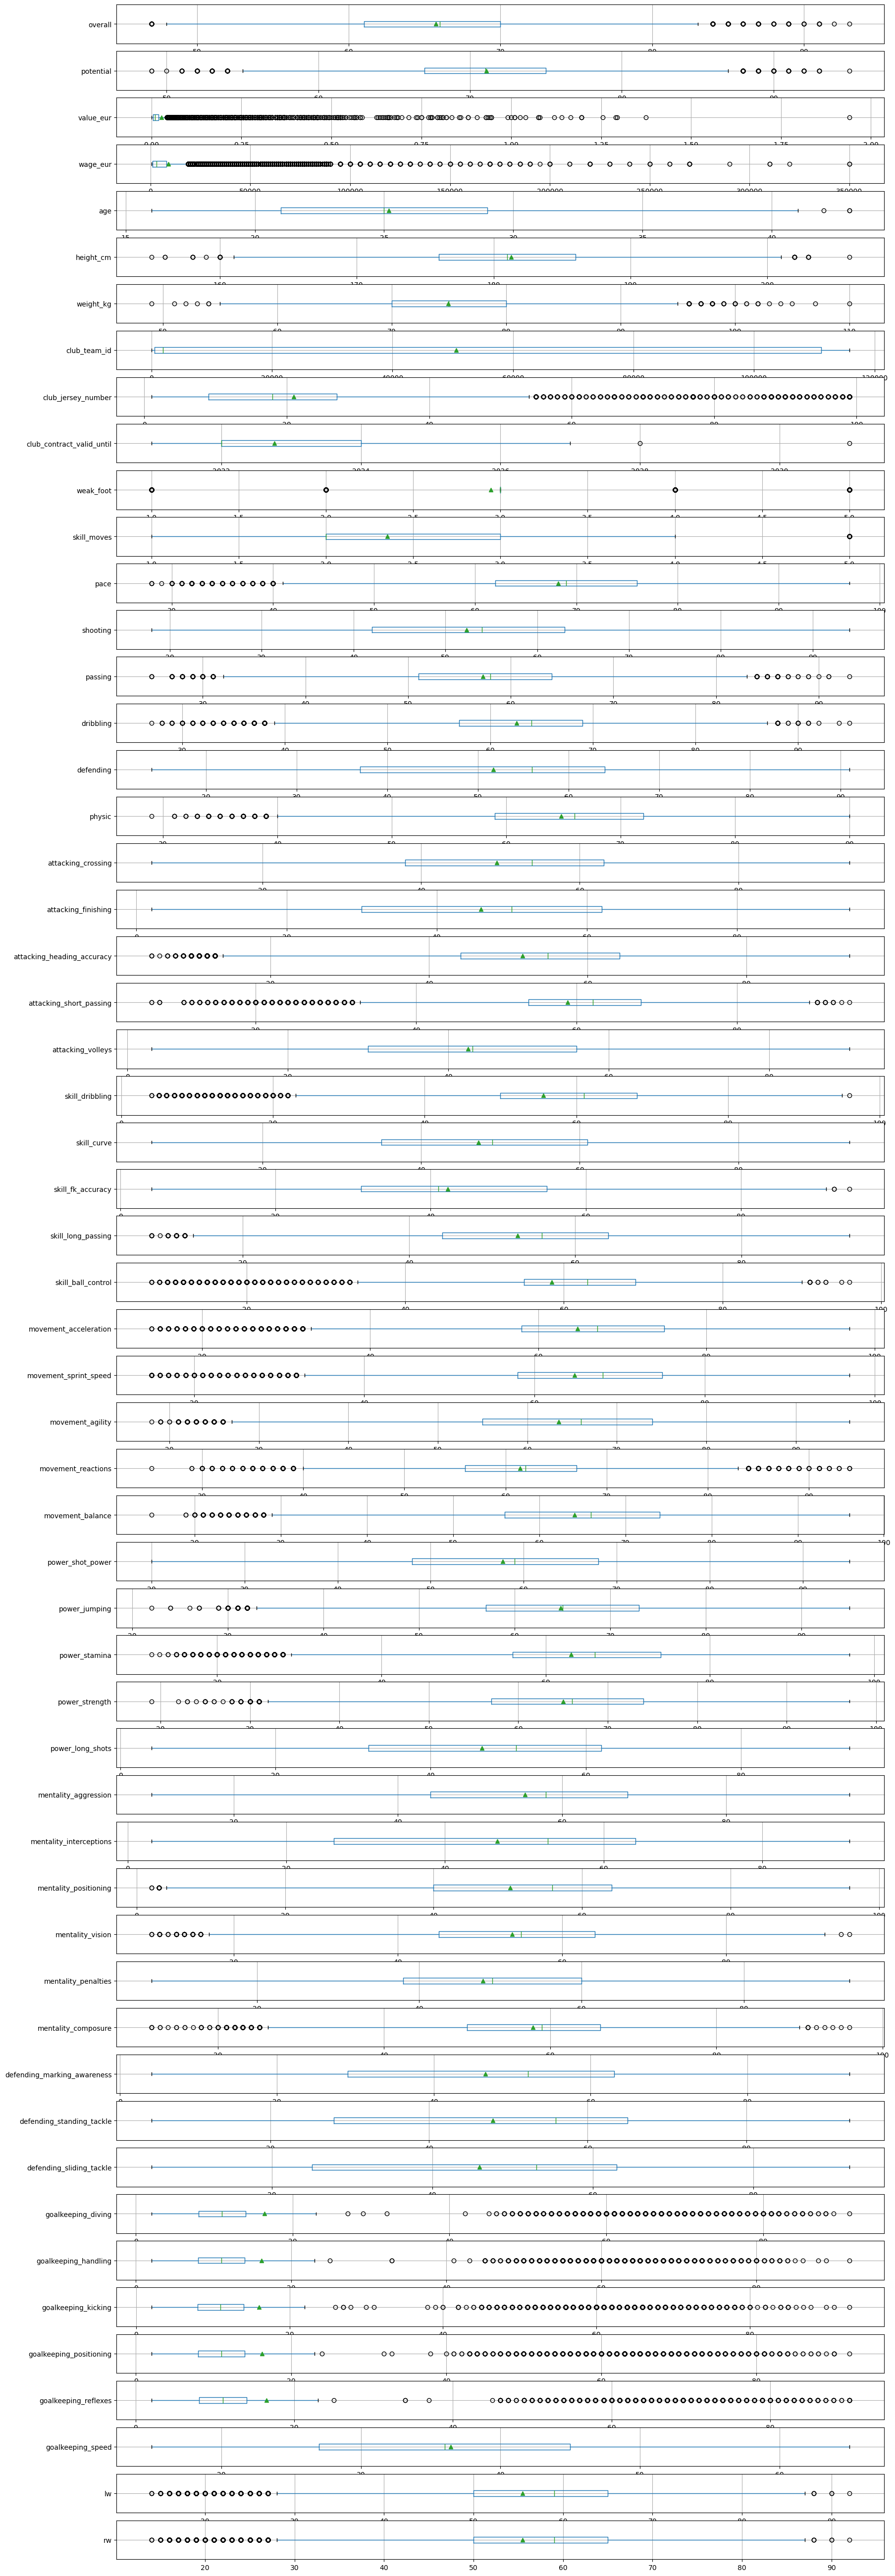

In [59]:


players_numeric_only = data.select_dtypes(include=["number"])
players_numeric_only.drop(
    columns=[
        "sofifa_id",
        "league_level",
        "nationality_id",
        "nation_team_id",
        "nation_jersey_number",
        "international_reputation",
        "release_clause_eur"
    ],
    inplace=True,
)

fig, axes = plt.subplots(len(players_numeric_only.columns), 1, figsize=(20, 67))

outliers_data=[]

for i, column in enumerate(players_numeric_only):
    Q1 = players_numeric_only[column].quantile(0.25)
    Q3 = players_numeric_only[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = players_numeric_only[
        (players_numeric_only[column] < lower_bound)
        | (players_numeric_only[column] > upper_bound)
    ]
    outliers_data.append({"Kolonne":column,"Q1":Q1,"Q3":Q3,"IQR":IQR,"Outliers":len(outliers),"Procent":(len(outliers)/len(players_numeric_only) * 100)})

    players_numeric_only[[column]].boxplot(vert=False, showmeans=True, ax=axes[i])
    
outliers_overview=pd.DataFrame(outliers_data)
display(outliers_overview.sort_values(by="Outliers",ascending=False))

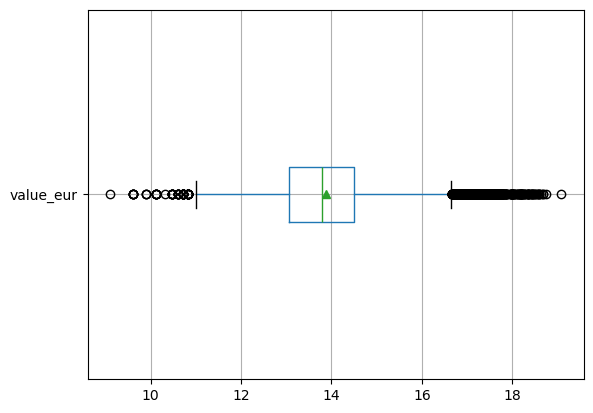

In [61]:
players_numeric_only.apply(np.log1p).boxplot(column="value_eur",vert=False, showmeans=True)

data_fixed = data
data_fixed["value_eur"] = np.log1p(data_fixed["value_eur"])


In [66]:
features = [
    "age",
    "potential",
    "overall",
    "player_positions"
]

X = data[features]
player_positions_ohe = X["player_positions"].str.split(", ").str.join("|").str.get_dummies()

X = pd.concat([X.drop(columns="player_positions"), player_positions_ohe], axis=1)

y = data_fixed["value_eur"]

display(X)
display(y)

,age,potential,overall,CAM,CB,CDM,CF,CM,GK,LB,LM,LW,LWB,RB,RM,RW,RWB,ST
0,34,93,93,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1
1,32,92,92,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2,36,91,91,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
3,29,91,91,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,30,91,91,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19234,22,52,47,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
19235,19,59,47,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
19236,21,55,47,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
19237,19,60,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


0        18.172219
1        18.598827
2        17.622173
3        18.675323
4        18.647816
           ...    
19234    11.156265
19235    11.608245
19236    11.512935
19237    11.608245
19238    11.608245
Name: value_eur, Length: 19165, dtype: float64

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=67
)

array([[ 0.80593406, -0.83448675,  0.03484313, ..., -0.25463805,
        -0.15629476, -0.46315445],
       [ 1.65206658,  0.97247646,  1.63307084, ..., -0.25463805,
        -0.15629476, -0.46315445],
       [-0.886331  , -1.16302551, -1.41809115, ..., -0.25463805,
        -0.15629476, -0.46315445],
       ...,
       [ 1.65206658, -1.3272949 , -0.40103715, ..., -0.25463805,
        -0.15629476, -0.46315445],
       [-0.46326473, -0.01313984, -0.1104503 , ..., -0.25463805,
        -0.15629476,  2.15910699],
       [ 0.80593406,  0.64393769,  1.34248398, ..., -0.25463805,
        -0.15629476,  2.15910699]])

In [72]:
import numpy as np


ols = LinearRegression()

ols.fit(X_train,y_train)
intercept,coef = ols.intercept_,ols.coef_
print("intercept:\n", np.expm1(intercept))
print("coef:\n",coef)

from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

y_hat_log = ols.predict(X_test)

y_hat = np.expm1(y_hat_log)
y_true = np.expm1(y_test)

mae = np.mean(np.abs(y_true - y_hat))
print(f"Mean absolut error: {mae:.2f}")

mse = mean_squared_error(y_true,y_hat)
print(f"Mean Squared Error (MSE): {mse:.2f}")
r2=r2_score(y_true ,y_hat)
print(f"R-squared (R2) Score: {r2:.2f}")
rmse = root_mean_squared_error(y_true, y_hat)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

intercept:
 1072402.9395267714
coef:
 [-5.50835582e-01  1.68722465e-02  1.32800943e+00 -3.74092601e-04
 -2.09870383e-02 -1.04498538e-02  2.79528099e-03  1.00148645e-02
 -7.66335019e-02 -1.05511302e-02  2.12200382e-04 -3.08350647e-03
 -2.64599430e-03 -1.13218155e-02 -6.64278221e-04  1.82897113e-03
 -2.04217253e-04  1.52725862e-02]
Mean absolut error: 749918.71
Mean Squared Error (MSE): 7322732148707.50
R-squared (R2) Score: 0.89
Root Mean Squared Error (RMSE): 2706054.72
